In [1]:
# import python libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import csv file 
df=pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Each row represents one Netflix title, either a Movie or a TV Show, along with its details such as title, director, cast, country, release year, rating, duration, and genre

In [4]:
df.shape


(8807, 12)

#### The dataset contains 8807 rows and 12 columns.


In [5]:
df.describe() # it was used to analyze summary statistics of numerical variables

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


#### It shows the distribution of the release_year column, indicating that most Netflix content was released in recent years



In [6]:
df.info() #  It gives an overview of the dataset structure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


#### It shows column names, data types, and non-null values.
#### The dataset contains mostly categorical variables and one numerical variable.


In [7]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum() #used to identify missing values in the dataset.

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### It shows the total number of null values present in each column.
#### From the output, it is observed that some columns contain missing values,which will need to be handled during data cleaning.


In [8]:
df["director"] = df["director"].fillna("unknown")
df["country"] = df["country"].fillna("not available")
df["cast"] = df["cast"].fillna("not available")
df["rating"] = df["rating"].fillna("not rated")
df["date_added"] = df["date_added"].fillna("not available")
df["duration"] = df["duration"].fillna("not available")

In [9]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,not available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",not available,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,not available,not available,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [10]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

#### The analysis shows that Movies are more common than TV Shows on Netflix.
#### This indicates that Netflix has a higher focus on movie content.
 

In [12]:
df['release_year'].value_counts().sort_index()


release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

#### This table shows the distribution of movies and TV shows by their release year. It reveals that content production increased significantly over time, with the highest concentration between 2017-2020. The oldest content in the dataset is from 1925, while the most recent is from 2021.

In [13]:
df['release_year'].min(), df['release_year'].max()


(1925, 2021)

#### Some titles have very old release years compared to most recent content,
#### which can be considered anomalies in the dataset.


<Axes: xlabel='release_year', ylabel='Count'>

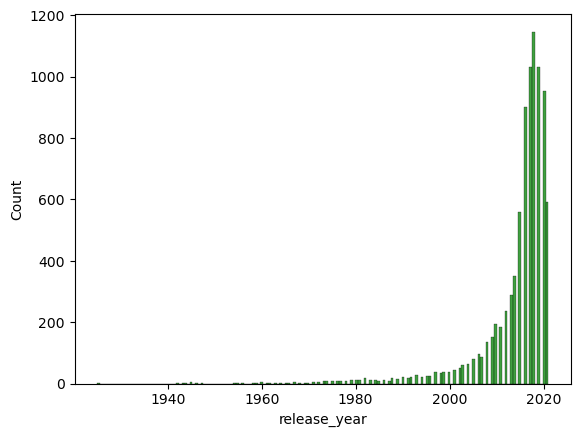

In [14]:
sns.histplot(df["release_year"],color="green")


#### Very few titles were released before 2000, while a significant increase is observed after 2015. This indicates that Netflix has rapidly expanded its content library in recent years.



In [15]:
director_available=df.groupby("type")["director"].count().reset_index(name="director_count")


In [16]:
director_available

,type,director_count
0,Movie,6131
1,TV Show,2676


([0, 1], [Text(0, 0, 'Movie'), Text(1, 0, 'TV Show')])

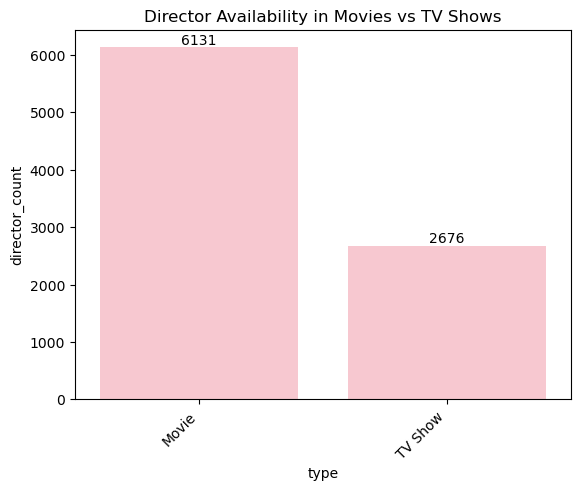

In [17]:
ax1=sns.barplot(x="type",y="director_count",data=director_available,color="pink")
for bars in ax1.containers:
    ax1.bar_label(bars)
plt.title("Director Availability in Movies vs TV Shows")
plt.xticks(rotation=45,ha="right")


#### The bar chart compares director availability in Movies and TV Shows. It is clear that Movies have a much larger number of directors (5943) compared to TV Shows (230), suggesting that the film industry has a wider pool of directors, while TV Shows rely on a relatively smaller group.

In [18]:
top10_directors = (
    df['director']
    .value_counts()
    .head(10)
    .reset_index()
)

top10_directors.columns = ['director', 'total_count']



In [19]:
top10_directors

,director,total_count
0,unknown,2634
1,Rajiv Chilaka,19
2,"Raúl Campos, Jan Suter",18
3,Suhas Kadav,16
4,Marcus Raboy,16
5,Jay Karas,14
6,Cathy Garcia-Molina,13
7,Martin Scorsese,12
8,Youssef Chahine,12
9,Jay Chapman,12


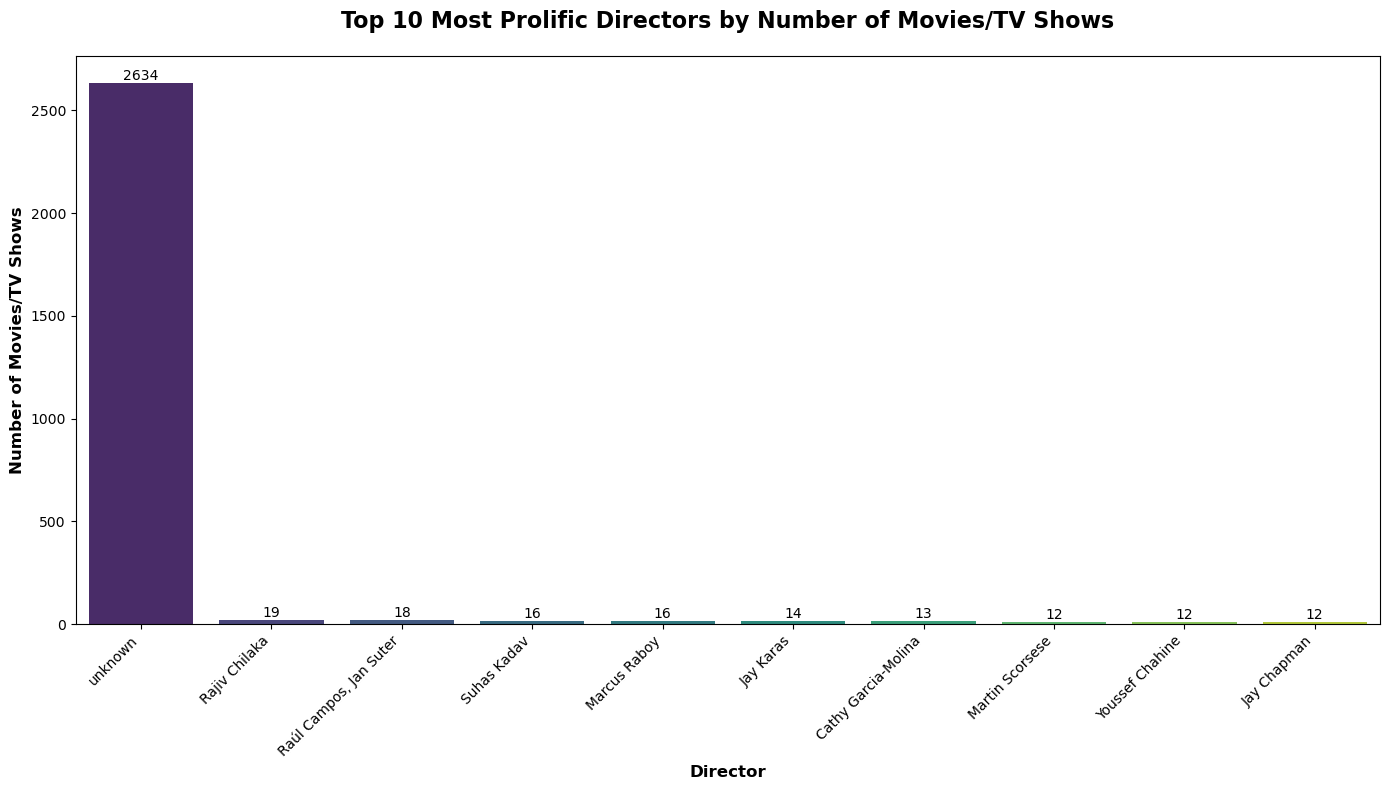

In [20]:

# Create the bar plot
plt.figure(figsize=(14, 8))
ax1 = sns.barplot(
    x="director", 
    y="total_count", 
    data=top10_directors,
    hue="director",  # Add hue to fix the warning
    palette="viridis",
    dodge=False,  # Important when using hue
    legend=False   # Hide legend since we don't need it
)

# Add value labels on bars
for bars in ax1.containers:
    ax1.bar_label(bars)

# Rotate x-axis labels properly
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add titles and labels
plt.title("Top 10 Most Prolific Directors by Number of Movies/TV Shows", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Director", fontsize=12, fontweight='bold')
plt.ylabel("Number of Movies/TV Shows", fontsize=12, fontweight='bold')

# Adjust layout
plt.tight_layout()
plt.show()



#### This bar chart displays the ten directors with the highest number of movie or TV show credits in the dataset. 

In [21]:

top10_tv_directors = (
    df[df['type'] == 'TV Show']
    .groupby('director')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='tv_show_count')
)




In [22]:
top10_tv_directors

,director,tv_show_count
0,unknown,2446
1,Alastair Fothergill,3
2,Iginio Straffi,2
3,Stan Lathan,2
4,Shin Won-ho,2
5,Ken Burns,2
6,Hsu Fu-chun,2
7,Rob Seidenglanz,2
8,Alejandro Lozano,1
9,Alex Gibney,1


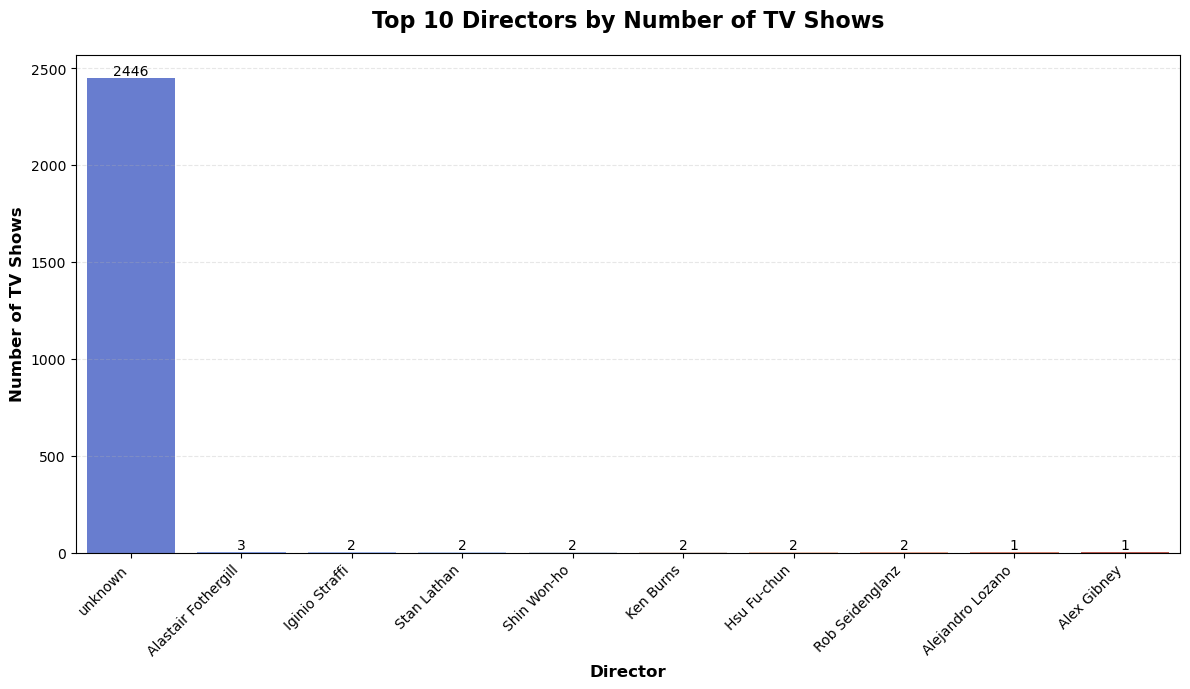

In [23]:

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x="director", 
    y="tv_show_count", 
    data=top10_tv_directors,
    hue="director",  # To use palette without warning
    palette="coolwarm",  # Different color scheme
    dodge=False,
    legend=False
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add titles and labels
plt.title("Top 10 Directors by Number of TV Shows", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Director", fontsize=12, fontweight='bold')
plt.ylabel("Number of TV Shows", fontsize=12, fontweight='bold')

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout
plt.tight_layout()
plt.show()

In [24]:
top10_movie_directors = (
    df[df['type'] == 'Movie']
    .groupby('director')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='movie_count')
)



In [25]:
top10_movie_directors

,director,movie_count
0,unknown,188
1,Rajiv Chilaka,19
2,"Raúl Campos, Jan Suter",18
3,Suhas Kadav,16
4,Marcus Raboy,15
5,Jay Karas,14
6,Cathy Garcia-Molina,13
7,Martin Scorsese,12
8,Jay Chapman,12
9,Youssef Chahine,12


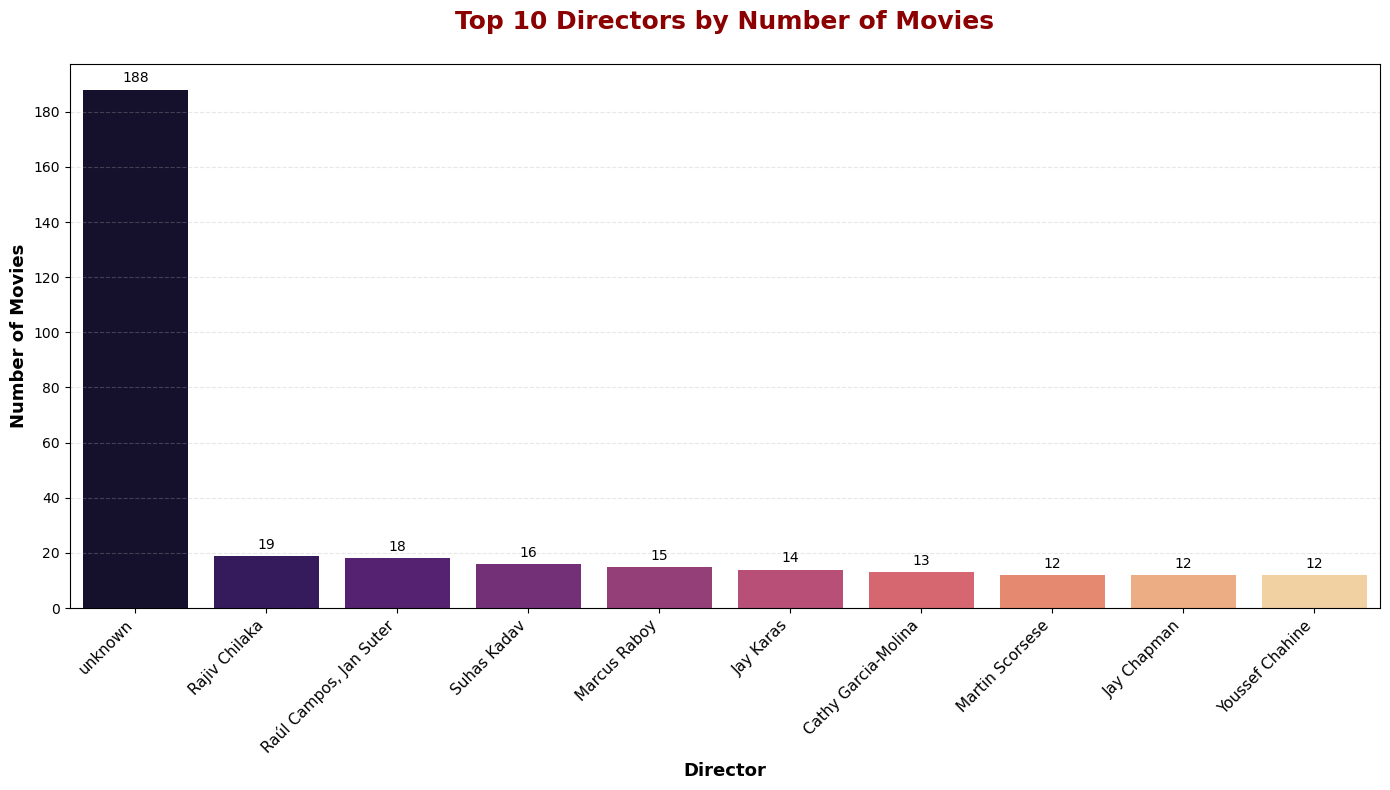

In [26]:

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x="director", 
    y="movie_count", 
    data=top10_movie_directors,
    hue="director",
    palette="magma",  # Different color scheme for movies
    dodge=False,
    legend=False
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add titles and labels
plt.title("Top 10 Directors by Number of Movies", 
          fontsize=18, pad=25, fontweight='bold', color='darkred')
plt.xlabel("Director", fontsize=13, fontweight='bold')
plt.ylabel("Number of Movies", fontsize=13, fontweight='bold')

# Add grid
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Set y-axis to integer values
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

In [27]:
top10_movie_country=df[df["type"]=="Movie"].groupby("country").size().reset_index(name="movie_count").sort_values(by="movie_count",ascending=False).head(10)

In [29]:
top10_movie_country

,country,movie_count
525,United States,2058
218,India,893
651,not available,440
440,United Kingdom,206
50,Canada,122
384,Spain,97
128,Egypt,92
319,Nigeria,86
238,Indonesia,77
428,Turkey,76


Text(0.5, 1.0, 'TOP 10 COUNTRY BY NO OF MOVIE')

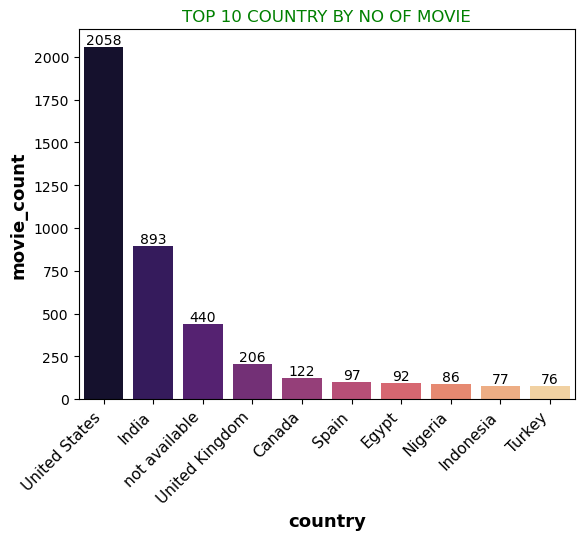

In [30]:
ax2=sns.barplot(x="country",y="movie_count",hue="country",legend=False,data=top10_movie_country,palette="magma")

plt.xticks(rotation=45,ha='right',fontsize=11)
for bars in ax2.containers:
    ax2.bar_label(bars)
plt.xlabel("country", fontsize=13, fontweight='bold')
plt.ylabel("movie_count", fontsize=13, fontweight='bold') 
plt.title("TOP 10 COUNTRY BY NO OF MOVIE",color='GREEN')

In [31]:
top10_TV_Show_country=df[df["type"]=="TV Show"].groupby("country").size().reset_index(name="TV Show_count").sort_values(by="TV Show_count",ascending=False).head(10)

In [32]:
top10_TV_Show_country

,country,TV Show_count
160,United States,760
196,not available,391
140,United Kingdom,213
83,Japan,169
120,South Korea,158
66,India,79
132,Taiwan,68
17,Canada,59
47,France,49
4,Australia,48


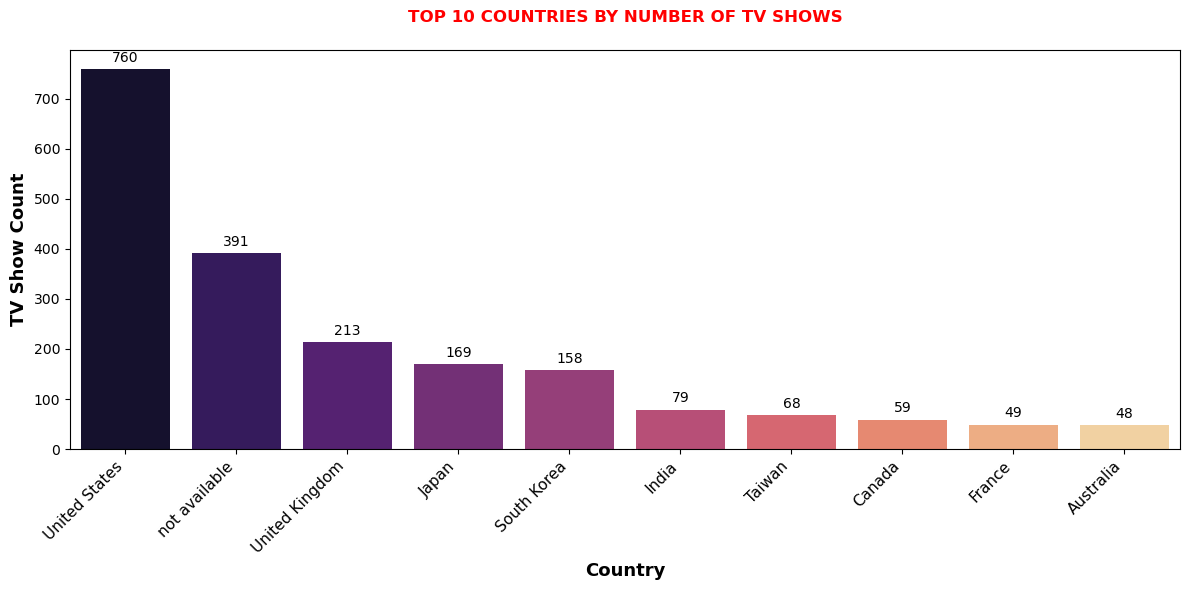

In [33]:
# Pehle ensure karo variable name sahi hai
# Agar aapka variable 'top10_TV_Show_country' hai (underscore ke saath)
top10_TV_Show_country = df[df["type"] == "TV Show"].groupby("country").size().reset_index(name="TV_Show_count").sort_values(by="TV_Show_count", ascending=False).head(10)

# Ab plot karo
plt.figure(figsize=(12, 6))
ax3 = sns.barplot(x="country", y="TV_Show_count", hue="country", 
                  legend=False, data=top10_TV_Show_country, palette="magma")

# Customize the plot
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add labels on bars
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.0f', padding=3)

# Set labels and title
plt.xlabel("Country", fontsize=13, fontweight='bold')
plt.ylabel("TV Show Count", fontsize=13, fontweight='bold')
plt.title("TOP 10 COUNTRIES BY NUMBER OF TV SHOWS", color='red', fontweight='bold', pad=20)

# Adjust layout
plt.tight_layout()
plt.show()

#### In this project, Exploratory Data Analysis (EDA) was performed on the Netflix dataset using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn. Data cleaning and visualization were used to analyze content distribution and trends. The analysis showed that movies dominate the platform and content addition has increased over the years. This project improved my practical understanding of EDA and data analysis.